<a href="https://colab.research.google.com/github/shreeusesgit/Neural-Networks-Project/blob/main/Linear_Regression_house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

R2 score:0.6341189942329308
RMSE: 52975.71771337444


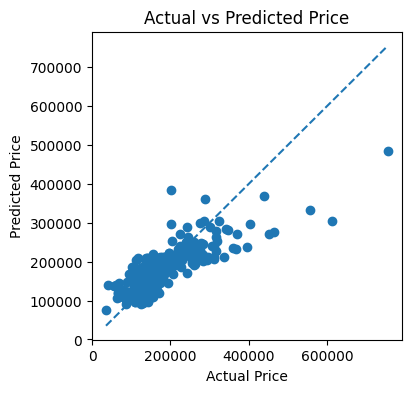

Predicted price for new house: 240377.51479738828


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("train.csv")
df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]
df = df.dropna()
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R2 score:{r2}")
print(f"RMSE: {rmse}")


plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--',)
plt.show()

new_house = pd.DataFrame([[2000, 3, 2]],
                         columns=['GrLivArea', 'BedroomAbvGr', 'FullBath'])

new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)

print("Predicted price for new house:", predicted_price[0])
